# B站热门视频流量规律分析
**业务目标**：通过分析 B站热门榜数据，回答"什么样的内容更容易火"，给创作者选题和平台运营提供数据参考。
**数据来源**：B站官方热门榜 API，三周采集（2026-07-26 / 08-02 / 08-10），合并去重后 1,926 条唯一热门视频。
**分析维度**：
1. 播放量整体分布特征（右偏 / 幂律分布）
2. 分区维度（流量 vs 互动意愿，爆款率）
3. UP主维度（集中度 / 分层 / 稳定性）
4. 发布时间与时长维度（星期 / 时长分箱）
5. 相关性与互动质量（互动率 vs 播放量，弹幕密度）
6. 爆款特征画像（爆款 vs 普通组对比）
7. 爆款预测模型（逻辑回归）

## 一、播放量分布特征输出播放量的核心统计指标，并量化数据右偏程度。
**统计指标**：均值、中位数、标准差、四分位数、最大值、最小值。
**右偏量化**：均值 ÷ 中位数（预期 1.52），比值越大说明均值被头部大播放量拉高越多，中位数才是大众水平。
**层级占比**：按播放量分位划分尾部（<30%）/ 腰部（30%-90%）/ 头部爆款（≥90%）/ 超级爆款（≥99%），看爆款的稀缺程度。

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# 设置中文字体，防止图里出现方框
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取阶段一清洗后的数据
df = pd.read_csv('../data/b站数据_清洗后.csv', encoding='utf-8-sig')

# ============ 1. 核心指标输出 ============
p = df['播放量']
print('播放量描述统计:')
print('均值:', round(p.mean()))
print('中位数:', round(p.median()))
print('标准差:', round(p.std()))
print('25%分位:', round(p.quantile(0.25)))
print('75%分位:', round(p.quantile(0.75)))
print('最大值:', round(p.max()))
print('最小值:', round(p.min()))

# 右偏程度：均值远大于中位数说明数据右偏，被头部大播放量拉高
print('均值 / 中位数:', round(p.mean() / p.median(), 2))
print('中位数占均值比例:', round(p.median() / p.mean() * 100, 1), '%')

# ============ 2. 各层级占比 ============
print('各播放层级占比:')
print(df['播放分层'].value_counts(normalize=True).round(4).to_string())

播放量描述统计:
均值: 1539581
中位数: 1014094
标准差: 1571630
25%分位: 477025
75%分位: 2002628
最大值: 12141518
最小值: 54669
均值 / 中位数: 1.52
中位数占均值比例: 65.9 %
各播放层级占比:
播放分层
腰部普通     0.5997
尾部低播放    0.3002
头部爆款     0.0901
超级爆款     0.0100


## 二、播放量分布可视化
**原始直方图**：播放量挤在左侧低播放区，右侧拖出长尾，直观看到右偏。
**取对数直方图**：播放量跨度 700 倍，取 log10 后接近钟形，验证服从**幂律分布**（少数视频拿走大部分播放）。
**分区箱线图**：只保留视频数 ≥ 5 的分区，看中位线（哪个分区播放高）和箱体宽度（哪个分区波动大）。

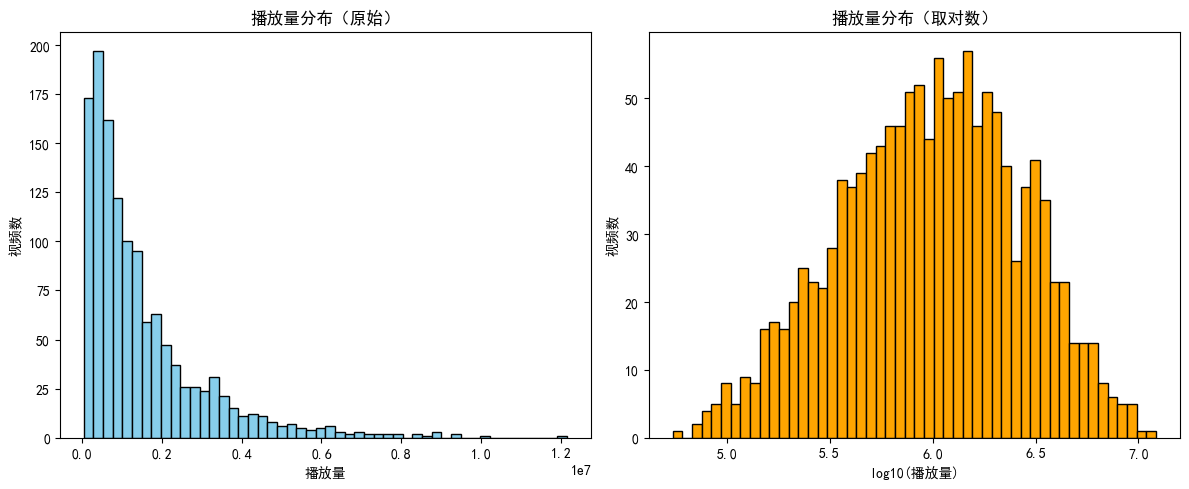

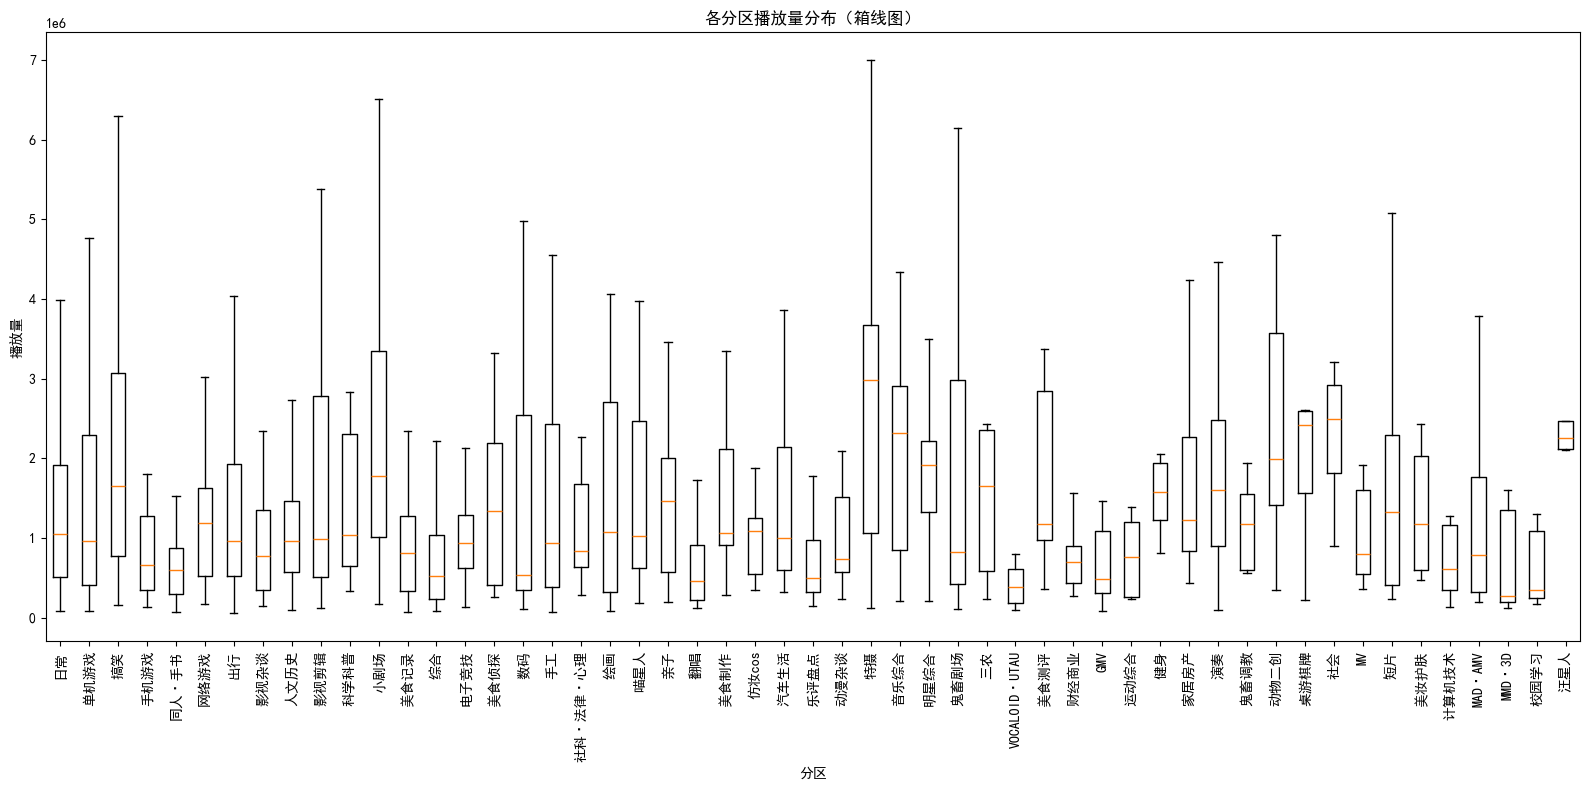

In [14]:
# ============ 3. 画图1：原始播放量分布直方图 ============
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['播放量'], bins=50, color='skyblue', edgecolor='black')
plt.title('播放量分布（原始）')
plt.xlabel('播放量')
plt.ylabel('视频数')

# ============ 4. 画图2：取对数后的分布 ============
import numpy as np
plt.subplot(1, 2, 2)
plt.hist(np.log10(df['播放量'] + 1), bins=50, color='orange', edgecolor='black')
plt.title('播放量分布（取对数）')
plt.xlabel('log10(播放量)')
plt.ylabel('视频数')

plt.tight_layout()
plt.savefig('../reports/图0_播放量分布.png', dpi=150)
plt.show()

# ============ 5. 画图3：按分区播放量箱线图 ============
# 只画视频数大于等于 5 的分区，避免样本太少
top_parts = df['分区'].value_counts()
parts = top_parts[top_parts >= 5].index

data_for_box = []
labels = []
for part in parts:
    data_for_box.append(df[df['分区'] == part]['播放量'].values)
    labels.append(part)

plt.figure(figsize=(16, 8))
plt.boxplot(data_for_box, tick_labels=labels, showfliers=False)  # 不画离群点，否则图太乱
plt.title('各分区播放量分布（箱线图）')
plt.xlabel('分区')
plt.ylabel('播放量')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../reports/图0_分区箱线图.png', dpi=150)
plt.show()

## 三、分区维度：流量与互动从**流量**和**互动**两视角统计各分区表现（只统计视频数 ≥ 5 的分区）。
**统计口径**：播放量中位数（典型流量）、三连率均值（观众认可度）、爆款占比（该分区内头部爆款占比，反映"在这投稿更容易火"）。
**分区内相对排名**：给每条视频算它在自己分区内的播放排名百分比，消除跨分区流量基数差异——跨分区比绝对播放量不公平。

In [15]:
# ============ 1. 分区汇总统计 ============
# 只统计视频数大于等于 5 的分区，样本太少的不能代表分区水平
part_stats = df[df['分区'].isin(df['分区'].value_counts()[df['分区'].value_counts() >= 5].index)]

stats = part_stats.groupby('分区').agg(
    视频数=('BV号', 'count'),
    播放量中位数=('播放量', 'median'),
    播放量均值=('播放量', 'mean'),
    三连率均值=('三连率', 'mean'),
    点赞率均值=('点赞率', 'mean'),
).round(2)

# 爆款占比：每个分区里头部爆款+超级爆款占多少
top_count = part_stats[part_stats['播放分层'].isin(['头部爆款', '超级爆款'])].groupby('分区').size()
stats['爆款数'] = top_count
stats['爆款占比'] = (stats['爆款数'] / stats['视频数']).round(3)

# 按播放量中位数排序
stats = stats.sort_values('播放量中位数', ascending=False)
print('分区综合表（按播放中位数排序）:')
print(stats.head(15).to_string())

# ============ 2. 分区内相对排名 ============
# 每条视频算它在自己分区内的播放排名百分比，0=最强
df['分区内排名'] = df.groupby('分区')['播放量'].rank(pct=True)
print('\n分区内排名最高的 10 条:')
print(df.nlargest(10, '分区内排名')[['标题', 'UP主', '分区', '播放量', '分区内排名']].to_string())

分区综合表（按播放中位数排序）:
      视频数     播放量中位数       播放量均值  三连率均值  点赞率均值   爆款数   爆款占比
分区                                                         
特摄     11  2986006.0  3055329.36   0.08   0.06   3.0  0.273
社会      7  2490560.0  2566579.00   0.06   0.05   2.0  0.286
桌游棋牌    7  2419401.0  2463782.43   0.04   0.03   NaN    NaN
音乐综合   11  2313798.0  2091488.91   0.11   0.08   2.0  0.182
汪星人     5  2261338.0  3063044.40   0.08   0.06   1.0  0.200
动物二创    7  1998513.0  2447080.14   0.06   0.04   3.0  0.429
明星综合   11  1917314.0  1905903.55   0.06   0.03   NaN    NaN
小剧场    28  1785152.0  2435905.93   0.08   0.06   5.0  0.179
搞笑     98  1659153.5  2250480.69   0.08   0.06  17.0  0.173
三农     10  1653628.5  1908342.10   0.09   0.08   NaN    NaN
演奏      7  1608135.0  1847580.43   0.15   0.11   1.0  0.143
健身      8  1583636.5  1691968.12   0.05   0.04   1.0  0.125
亲子     16  1463045.5  1464033.31   0.11   0.09   1.0  0.062
美食侦探   22  1345348.0  1625737.00   0.08   0.06   2.0  0.091
短片      7  1331659.0  1

## 四、分区维度可视化
**播放量中位数 Top15**：横向条形图展示流量最高的 15 个分区。
**流量 vs 互动意愿散点图**：X 轴播放中位数、Y 轴三连率。
**关键发现**：流量越高的分区，三连率往往越低——大众区（搞笑、小剧场）靠"广撒网"，小众创作区（VOCALOID、绘画、MAD）靠"核心粉"，播放少但质量高。

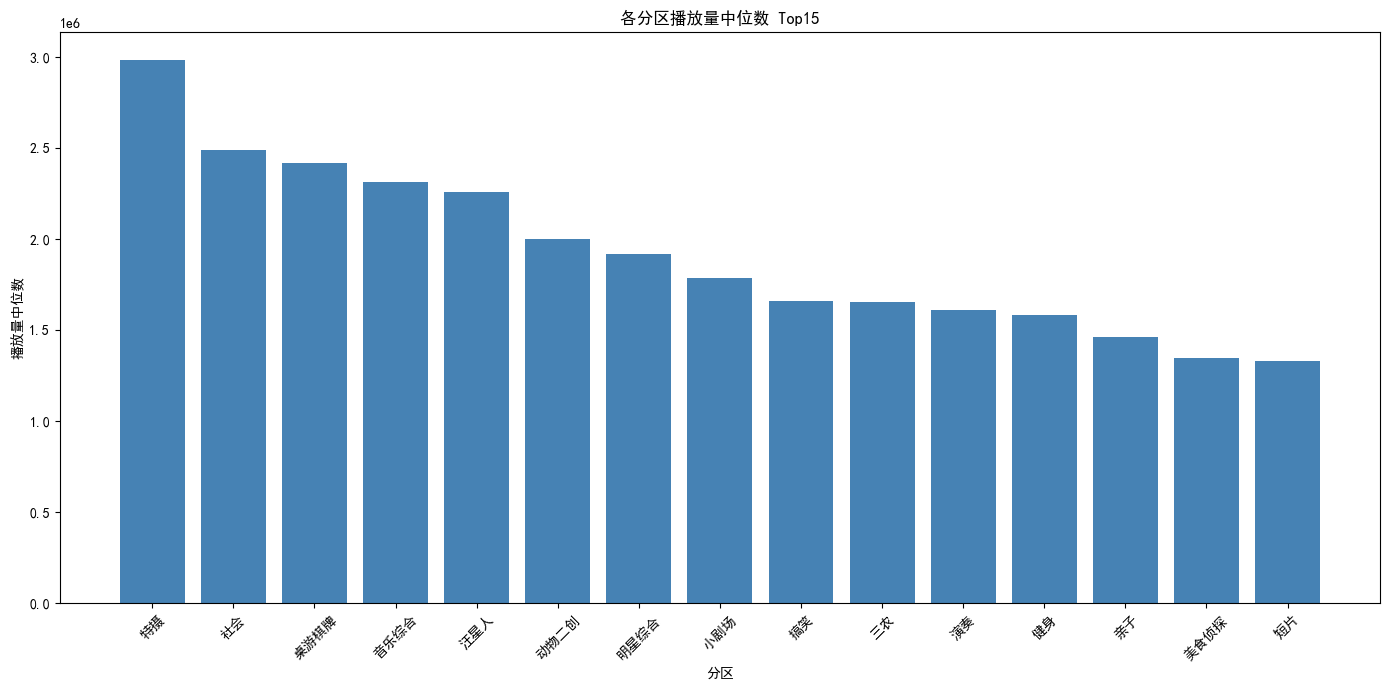

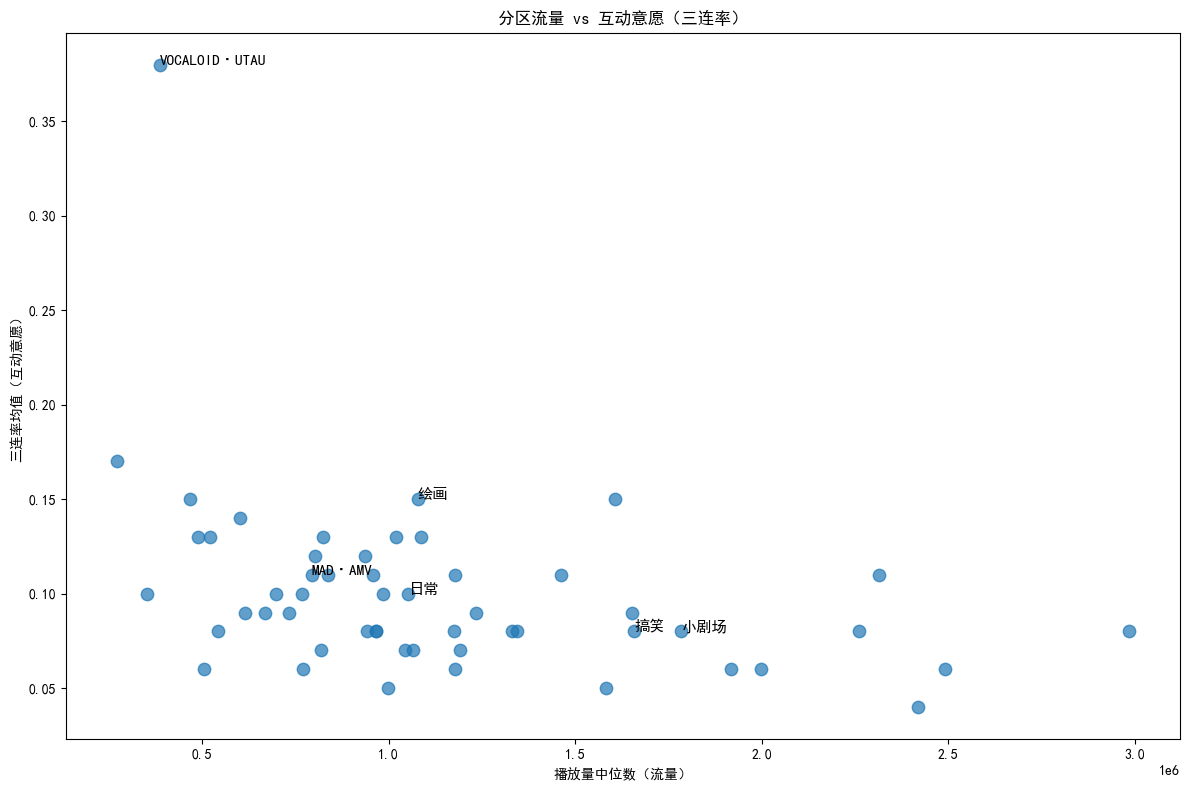

In [16]:

# ============ 3. 画图：分区播放量中位数 Top15 ============
top15 = stats.head(15).reset_index()
plt.figure(figsize=(14, 7))
plt.bar(top15['分区'], top15['播放量中位数'], color='steelblue')
plt.title('各分区播放量中位数 Top15')
plt.xlabel('分区')
plt.ylabel('播放量中位数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/图1_分区播放量中位数.png', dpi=150)
plt.show()

# ============ 4. 画图：互动意愿 vs 流量 ============
# 横轴是播放中位数（流量），纵轴是三连率（互动意愿）
plt.figure(figsize=(12, 8))
plt.scatter(stats['播放量中位数'], stats['三连率均值'], s=80, alpha=0.7)
# 标注几个关键分区
for part in ['搞笑', '绘画', '小剧场', '日常', 'VOCALOID·UTAU', 'MAD·AMV']:
    if part in stats.index:
        row = stats.loc[part]
        plt.annotate(part, (row['播放量中位数'], row['三连率均值']),
                     fontsize=11)
plt.title('分区流量 vs 互动意愿（三连率）')
plt.xlabel('播放量中位数（流量）')
plt.ylabel('三连率均值（互动意愿）')
plt.tight_layout()
plt.savefig('../reports/图1_流量vs互动.png', dpi=150)
plt.show()

## 五、UP主维度分析按 UP主 聚合，只保留出现 ≥ 2 次的（1 次的无法计算稳定性）。
**UP主分层**：按平均播放分位切头部 20% / 腰部 60% / 尾部 20%，对比各层级播放表现。
**流量稳定性**：变异系数（标准差 ÷ 均值）衡量波动，小=稳定型，大=赌爆款型。
**小 UP 出爆款检验**：检验"账号平均播放低但单条进爆款"的样本。
**放宽到出现 1 次后预期结果仍为 0**：能上榜就说明已火，小 UP 平均播放低不可能单条冲到 116 万爆款线（日均播放 q90）——这是二八效应的极端证明，不是 bug。

In [17]:

# ============ 1. UP 主汇总 ============
up_stats = df.groupby('UP主').agg(
    视频数=('BV号', 'count'),
    总播放=('播放量', 'sum'),
    平均播放=('播放量', 'mean'),
    中位播放=('播放量', 'median'),
).round(0)

# 只保留出现在热门榜上至少 2 次的 UP 主（1 次的无法算稳定性）
multi = up_stats[up_stats['视频数'] >= 2].copy()
print('热门榜 UP 主总数:', len(up_stats))
print('出现 >=2 次的 UP 主:', len(multi))

# ============ 2. UP 主分层 ============
# 按平均播放量分位：前 20% 头部、中间 60% 腰部、后 20% 尾部
q20 = multi['平均播放'].quantile(0.20)
q80 = multi['平均播放'].quantile(0.80)

def up_level(avg):
    if avg >= q80:
        return '头部'
    if avg >= q20:
        return '腰部'
    return '尾部'

multi['UP主层级'] = multi['平均播放'].apply(up_level)
print('UP主层级分布:')
print(multi['UP主层级'].value_counts().to_string())

# ============ 3. 各层级播放表现 ============
print('\n各层级播放表现:')
print(multi.groupby('UP主层级')['平均播放'].agg(['count', 'mean', 'median']).round(0).to_string())

# ============ 4. 账号流量稳定性 ============
# 每个 UP 主有多条视频时，算它的播放量波动（标准差 / 均值 = 变异系数）
var_data = []
for up, group in df.groupby('UP主'):
    if len(group) >= 2:
        vals = group['播放量'].values
        cv = np.std(vals) / np.mean(vals)   # 变异系数：越大说明波动越大
        var_data.append({'UP主': up, '波动系数': cv})

var_df = pd.DataFrame(var_data)
multi = multi.merge(var_df, on='UP主', how='left')

print('\n头部 UP 主波动情况:')
head_up = multi[multi['UP主层级'] == '头部'].sort_values('平均播放', ascending=False)
print(head_up[['UP主', '视频数', '平均播放', '波动系数']].head(10).to_string())

# ============ 5. 小 UP 出爆款 ============
# 账号平均播放 < q20（尾部），但某条视频进了头部爆款 = 内容驱动型爆款
tail_ups = set(multi[multi['UP主层级'] == '尾部'].index)

small_up_hits = df[df['UP主'].isin(tail_ups) & df['播放分层'].isin(['头部爆款', '超级爆款'])]
print('\n小 UP 出爆款的样本数:', len(small_up_hits))
print('小 UP 出爆款 Top10:')
print(small_up_hits.sort_values('播放量', ascending=False)[['标题', 'UP主', '分区', '播放量', '播放分层']].head(10).to_string())
# ============ 6. 小 UP 出爆款（放宽到出现1次） ============
import pandas as pd

df = pd.read_csv('../data/b站数据_清洗后.csv', encoding='utf-8-sig')

up_stats = df.groupby('UP主').agg(
    视频数=('BV号', 'count'),
    平均播放=('播放量', 'mean'),
).round(0)

q30 = up_stats['平均播放'].quantile(0.30)
small_ups = set(up_stats[up_stats['平均播放'] < q30].index)
print('小 UP 数量:', len(small_ups))

q90 = df['日均播放'].quantile(0.90)
hits = df[df['UP主'].isin(small_ups) & (df['日均播放'] >= q90)]
print('小 UP 出爆款样本数(日均口径):', len(hits))
print('其中一次性爆款:', len(hits[hits['UP主'].map(up_stats['视频数']) == 1]))
# 先把视频数并到 hits 里
hits = hits.copy()
hits['视频数'] = hits['UP主'].map(up_stats['视频数'])

print('\n小 UP 出爆款 Top15:')
print(hits.sort_values('播放量', ascending=False)[['标题', 'UP主', '分区', '播放量', '视频数']].head(15).to_string())

热门榜 UP 主总数: 1066
出现 >=2 次的 UP 主: 153
UP主层级分布:
UP主层级
腰部    91
尾部    31
头部    31

各层级播放表现:
       count       mean     median
UP主层级                             
头部        31  4030313.0  3945774.0
尾部        31   526582.0   530720.0
腰部        91  1561578.0  1433264.0

头部 UP 主波动情况:
               UP主  视频数       平均播放      波动系数
25           东方日出哇    2  7933864.0  0.117754
145          陈翔六点半    2  7916004.0  0.105742
76            影视飓风    3  5610128.0  0.414366
149          鲤鱼Ace    3  5115814.0  0.579038
151  麦克阿瑟MacArthur    2  5015293.0  0.455229
32         伤心欲茄222    6  4907856.0  0.275569
65           小椰子专栏    2  4654778.0  0.797145
23           与山0v0    3  4443364.0  0.702187
28         争取最后的自由    3  4267731.0  0.612166
24        世界记忆大师龙雅    2  4099299.0  0.845504

小 UP 出爆款的样本数: 0
小 UP 出爆款 Top10:
Empty DataFrame
Columns: [标题, UP主, 分区, 播放量, 播放分层]
Index: []
小 UP 数量: 320
小 UP 出爆款样本数(日均口径): 0
其中一次性爆款: 0

小 UP 出爆款 Top15:
Empty DataFrame
Columns: [标题, UP主, 分区, 播放量, 视频数]
Index: []


## 六、UP主集中度曲线绘制
UP主 播放量集中度曲线（洛伦兹曲线）：X 轴 UP主 按播放从高到低，Y 轴累计播放占比。曲线越陡 → 流量越集中在头部；画 50%、90% 参考线看交点人数。
**结论预期**：前 14% 的 UP主（151人）贡献 50% 播放，前 56% 贡献 90%——头部高度集中，长尾很长。

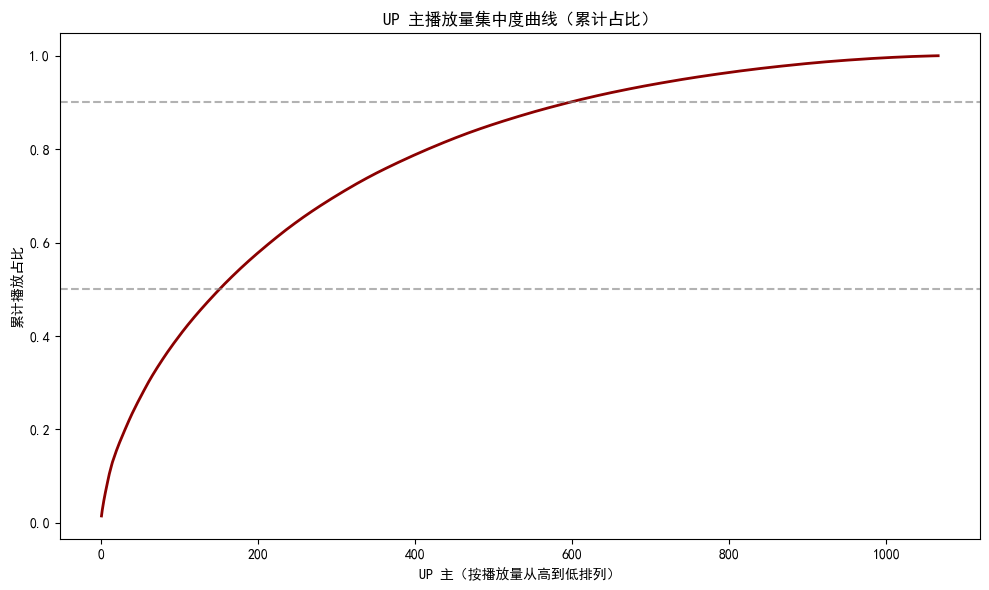

前 151 个 UP 主（占 14%）贡献了 50% 的播放
前 416 个 UP 主（占 39%）贡献了 80% 的播放
前 596 个 UP 主（占 56%）贡献了 90% 的播放


In [18]:
# ============ 7. 画图：UP主累计播放集中度 ============
up_total = df.groupby('UP主')['播放量'].sum().sort_values(ascending=False)
cum = up_total.cumsum() / up_total.sum()
x = list(range(1, len(up_total) + 1))

plt.figure(figsize=(10, 6))
plt.plot(x, cum, color='darkred', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6)   # 50% 线
plt.axhline(y=0.9, color='gray', linestyle='--', alpha=0.6)   # 90% 线
plt.title('UP 主播放量集中度曲线（累计占比）')
plt.xlabel('UP 主（按播放量从高到低排列）')
plt.ylabel('累计播放占比')
plt.tight_layout()
plt.savefig('../reports/图2_UP主集中度.png', dpi=150)
plt.show()

# 输出集中度数字
for p in [0.5, 0.8, 0.9]:
    n = (cum <= p).sum()
    print('前 %d 个 UP 主（占 %d%%）贡献了 %.0f%% 的播放' % (n, round(n / len(up_total) * 100), p * 100))

import pandas as pd

df = pd.read_csv('../data/b站数据_清洗后.csv', encoding='utf-8-sig')

## 七、发布时间与时长维度
**星期分布**：用 dayofweek 提取星期，对比各天发布视频的播放中位数和视频数。
**快照偏差**：数据是热门榜近 7 天快照，采集日均为周日。周六视频最多但中位数最低，是刚发布就被采集。此结论仅反映样本内分布，不构成"黄金投稿日"结论。
**时长分箱**：0-1分钟 / 1-5分钟 / 5-15分钟 / 15分钟+，对比播放中位数和三连率。
**时长散点**：播放量取对数，观察时长与播放的关系。

星期维度（注意：受热门榜近7天快照影响，仅反映样本内分布）:
    视频数      播放中位数
周一   73  2543298.0
周二   71  2549060.0
周三  140  1983914.0
周四  278  1341062.0
周五  496   774364.0
周六  225   389712.0
周日   16  3603150.0


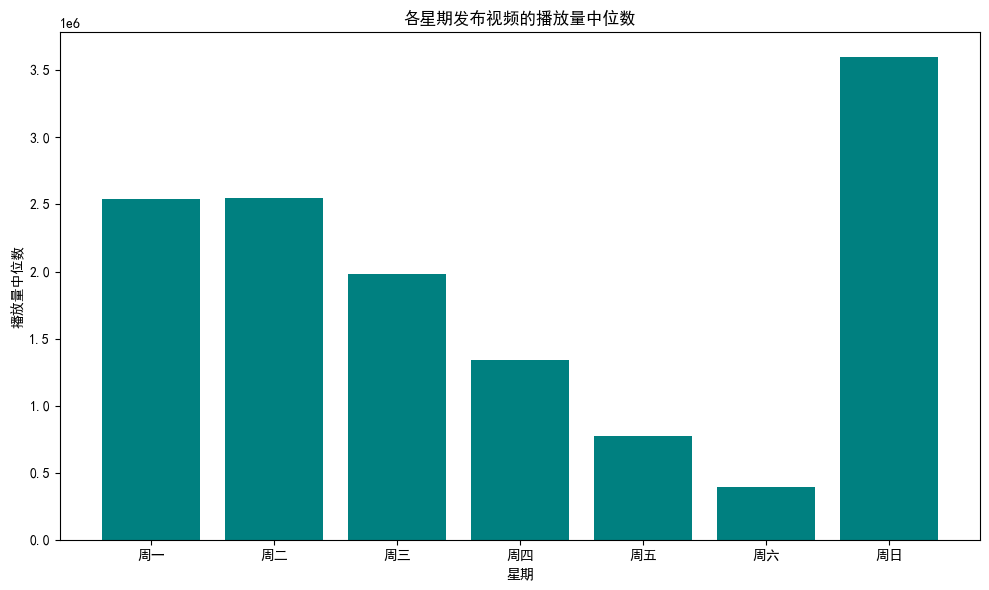


时长分箱统计:
        视频数      播放中位数   三连率均值
时长分箱                          
0-1分钟   150  1620062.0  0.1110
1-5分钟   576   972471.5  0.1039
5-15分钟  331   966851.0  0.0833
15分钟+   242   896820.5  0.0910


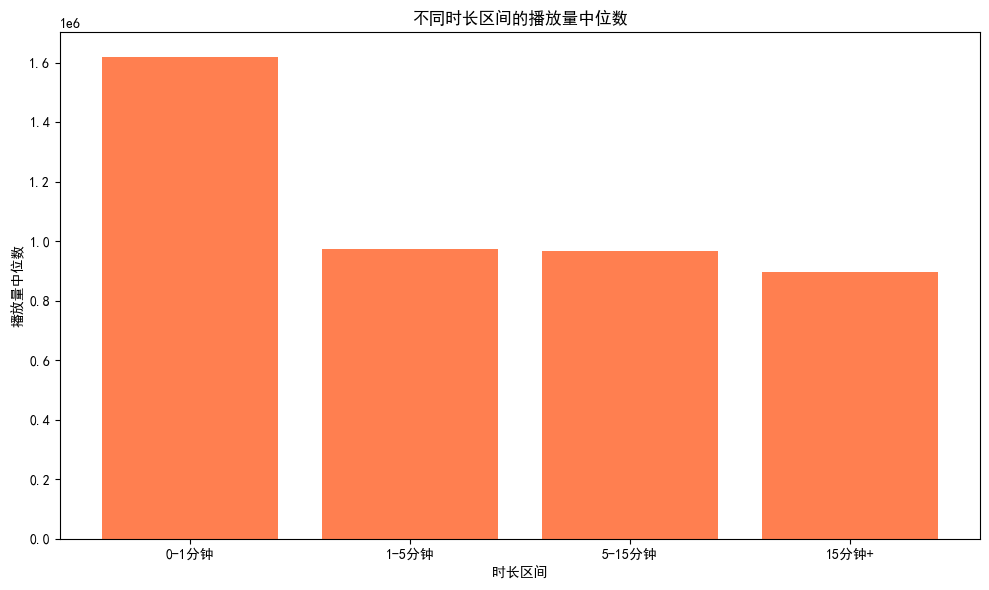

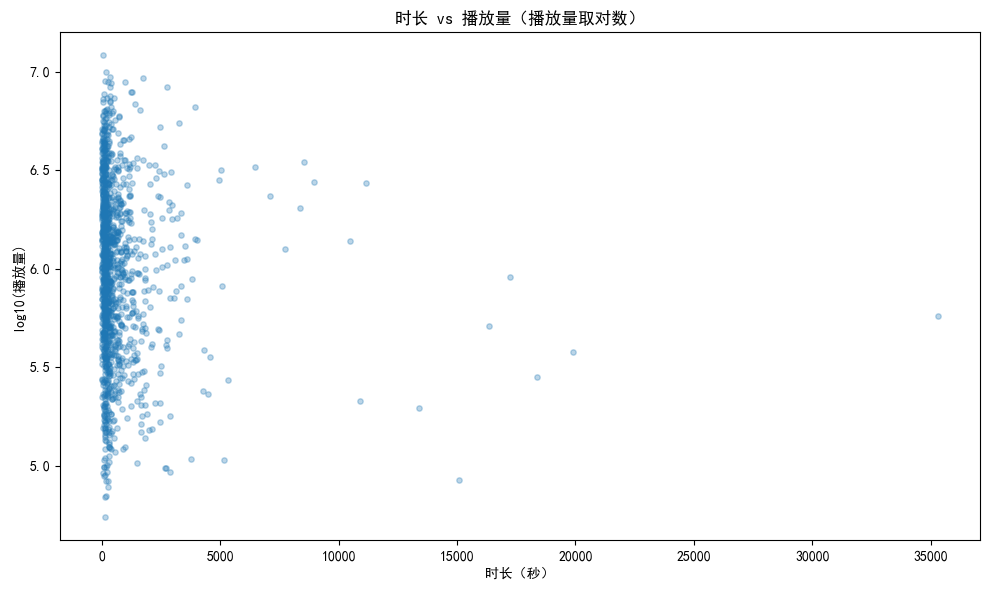

In [19]:
# 发布时间转成日期时间格式
df['发布时间'] = pd.to_datetime(df['发布时间'])

# ============ 1. 星期维度：各天发布的视频播放量中位数 ============
df['星期'] = df['发布时间'].dt.dayofweek   # 0=周一 6=周日

week_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
week_stats = df.groupby('星期').agg(
    视频数=('BV号', 'count'),
    播放中位数=('播放量', 'median'),
).round(0)
week_stats.index = week_names
print('星期维度（注意：受热门榜近7天快照影响，仅反映样本内分布）:')
print(week_stats.to_string())

# ============ 2. 画图：星期播放量中位数 ============
plt.figure(figsize=(10, 6))
plt.bar(week_stats.index, week_stats['播放中位数'], color='teal')
plt.title('各星期发布视频的播放量中位数')
plt.xlabel('星期')
plt.ylabel('播放量中位数')
plt.tight_layout()
plt.savefig('../reports/图3_星期播放.png', dpi=150)
plt.show()

# ============ 3. 时长分箱 ============
# 0-60秒 / 1-5分钟 / 5-15分钟 / 15分钟以上
bins = [0, 60, 300, 900, 100000]
labels = ['0-1分钟', '1-5分钟', '5-15分钟', '15分钟+']
df['时长分箱'] = pd.cut(df['时长秒'], bins=bins, labels=labels)

time_stats = df.groupby('时长分箱',observed=False).agg(
    视频数=('BV号', 'count'),
    播放中位数=('播放量', 'median'),
    三连率均值=('三连率', 'mean'),
).round(4)
print('\n时长分箱统计:')
print(time_stats.to_string())

# ============ 4. 画图：时长分箱播放中位数 ============
plt.figure(figsize=(10, 6))
plt.bar(time_stats.index, time_stats['播放中位数'], color='coral')
plt.title('不同时长区间的播放量中位数')
plt.xlabel('时长区间')
plt.ylabel('播放量中位数')
plt.tight_layout()
plt.savefig('../reports/图3_时长分箱.png', dpi=150)
plt.show()

# ============ 5. 画图：时长-播放量散点图 ============
# 播放量取对数，否则点全挤在左下角
plt.figure(figsize=(10, 6))
plt.scatter(df['时长秒'], np.log10(df['播放量']), alpha=0.3, s=15)
plt.title('时长 vs 播放量（播放量取对数）')
plt.xlabel('时长（秒）')
plt.ylabel('log10(播放量)')
plt.tight_layout()
plt.savefig('../reports/图3_时长散点.png', dpi=150)
plt.show()

## 八、相关性与互动质量（核心）用 Spearman 相关（看排名关系，适配偏态数据）分析互动与播放量的关系。
**绝对互动数**（点赞/评论等）：与播放强正相关（点赞约 0.80、收藏约 0.66）——规模效应。
**互动率**（点赞率/投币率等）：与播放量**全部负相关**（投币率 -0.52、评论率 -0.52）——播放越高，互动意愿反而越低。**弹幕密度是唯一强正相关（+0.543）**——弹幕是独立的质量维度。
**分层验证**：尾部低播放三连率最高（约 0.156），爆款最低（约 0.068），高播放 ≠ 高互动率。

In [20]:

# ============ 1. 绝对互动数 vs 播放量的 Spearman 相关 ============
# Spearman 看的是"排名关系"，对偏态数据比皮尔逊更稳
abs_cols = ['点赞数', '评论数', '弹幕数', '收藏数', '投币数', '分享数', '时长秒']
print('绝对互动数与播放量（Spearman）:')
print(df[['播放量'] + abs_cols].corr(method='spearman').loc['播放量'].round(3).to_string())

# ============ 2. 互动率 vs 播放量的 Spearman 相关 ============
rate_cols = ['点赞率', '评论率', '弹幕率', '收藏率', '投币率', '分享率']
print('\n互动率与播放量（Spearman）:')
print(df[['播放量'] + rate_cols].corr(method='spearman').loc['播放量'].round(3).to_string())

# ============ 3. 三连率、币赞比、弹幕密度与播放量的相关 ============
quality_cols = ['三连率', '币赞比', '弹幕密度']
print('\n质量指标与播放量（Spearman）:')
print(df[['播放量'] + quality_cols].corr(method='spearman').loc['播放量'].round(3).to_string())

# ============ 4. 高播放是否 = 高互动率？分组对比 ============
# 按播放分层，看各层级的互动率均值
grouped = df.groupby('播放分层')[rate_cols + quality_cols].mean().round(4)
print('\n各播放层级的互动率均值（验证高播放是否对应高互动率）:')
print(grouped.to_string())

# ============ 5. 爆款 vs 普通：互动指标差异 ============
# 爆款组 = 头部爆款 + 超级爆款
df['是否爆款'] = df['播放分层'].isin(['头部爆款', '超级爆款'])
hit = df[df['是否爆款']]
normal = df[~df['是否爆款']]

compare_cols = rate_cols + quality_cols
print('\n爆款组 vs 普通组互动指标对比:')
for col in compare_cols:
    h_avg = hit[col].mean()
    n_avg = normal[col].mean()
    print('%-8s 爆款=%.4f 普通=%.4f 差距=%.2f倍' % (col, h_avg, n_avg, h_avg / n_avg))


绝对互动数与播放量（Spearman）:
播放量    1.000
点赞数    0.797
评论数    0.525
弹幕数    0.361
收藏数    0.611
投币数    0.299
分享数    0.493
时长秒   -0.130

互动率与播放量（Spearman）:
播放量    1.000
点赞率   -0.344
评论率   -0.444
弹幕率   -0.392
收藏率   -0.306
投币率   -0.425
分享率   -0.215

质量指标与播放量（Spearman）:
播放量     1.000
三连率    -0.399
币赞比    -0.293
弹幕密度    0.543

各播放层级的互动率均值（验证高播放是否对应高互动率）:
          点赞率     评论率     弹幕率     收藏率     投币率     分享率     三连率     币赞比     弹幕密度
播放分层                                                                          
头部爆款   0.0534  0.0014  0.0022  0.0118  0.0070  0.0024  0.0722  0.1097  39.0828
尾部低播放  0.0912  0.0035  0.0048  0.0248  0.0158  0.0044  0.1317  0.1760   4.4360
腰部普通   0.0635  0.0020  0.0085  0.0128  0.0078  0.0029  0.0841  0.1203  15.0191
超级爆款   0.0425  0.0010  0.0007  0.0099  0.0056  0.0018  0.0579  0.1463  12.9024

爆款组 vs 普通组互动指标对比:
点赞率      爆款=0.0523 普通=0.0727 差距=0.72倍
评论率      爆款=0.0013 普通=0.0025 差距=0.53倍
弹幕率      爆款=0.0020 普通=0.0073 差距=0.28倍
收藏率      爆款=0.0116 普通=0.0168 差距=0.69倍
投币率      爆款=0

## 九、相关性热力图将绝对互动数之间的 Spearman 相关矩阵用热力图展示，颜色越红相关性越强。
重点看"播放量"行：点赞 0.80、收藏 0.66 强相关，投币 0.30 较弱。

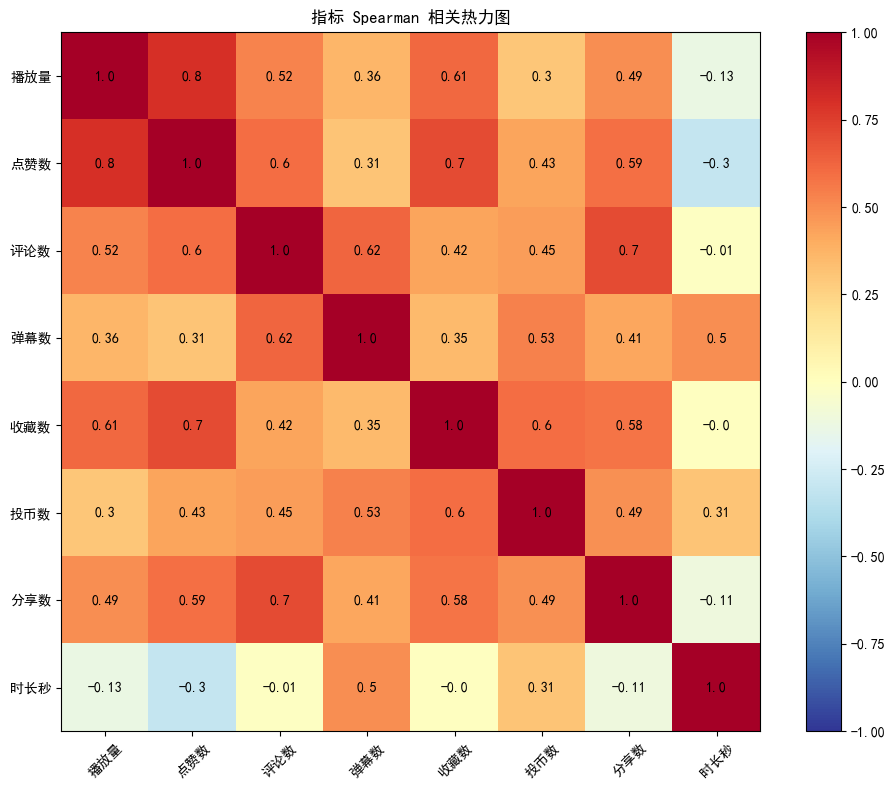

In [21]:
# ============ 6. 画图：热力图（Spearman） ============
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

corr = df[['播放量'] + abs_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, round(corr.iloc[i, j], 2),
                ha='center', va='center', fontsize=10)
plt.colorbar(im)
plt.title('指标 Spearman 相关热力图')
plt.tight_layout()
plt.savefig('../reports/图4_相关性热力图.png', dpi=150)
plt.show()

## 十、爆款特征画像将爆款组（头部爆款 + 超级爆款）与普通组分离，对比特征差异。
**分区差异**：爆款集中在哪些分区 + 爆款率（爆款数 ÷ 分区视频数，比绝对数更公平）。
**时长差异**：爆款组 vs 普通组的时长分箱占比。
**星期差异**：两组星期分布（受快照影响，仅作描述）。
**预期**：爆款中位时长 206 秒 vs 普通 257 秒（爆款更短）；弹幕密度 36.46 vs 11.49（3.2 倍）。

In [22]:
import pandas as pd

# 重新计算时长分箱
bins = [0, 60, 300, 900, 100000]
labels = ['0-1分钟', '1-5分钟', '5-15分钟', '15分钟+']
df['时长分箱'] = pd.cut(df['时长秒'], bins=bins, labels=labels)

# 时间处理
df['发布时间'] = pd.to_datetime(df['发布时间'])
df['星期'] = df['发布时间'].dt.dayofweek

# ✅先筛选copy，再操作，顺序修正
hit = df[df['播放分层'].isin(['头部爆款', '超级爆款'])].copy()
normal = df[~df['播放分层'].isin(['头部爆款', '超级爆款'])].copy()

print('爆款组:', len(hit), '普通组:', len(normal))

# ============ 1. 分区分布差异 ============
print('\n=== 爆款集中在哪些分区（Top10） ===')
hit_part = hit['分区'].value_counts().head(10)
total_part = df['分区'].value_counts()

for part, cnt in hit_part.items():
    ratio = cnt / hit['分区'].value_counts().sum()
    share = total_part.get(part, 0)
    all_ratio = share / len(df) * 100
    hit_rate = (cnt / share * 100) if share != 0 else 0
    print('%-12s 爆款数=%-4d 占爆款=%.1f%% 分区视频占比=%.1f%% 爆款率=%.1f%%'
          % (part, cnt, ratio * 100, all_ratio, hit_rate))

# ============ 2. 时长分布差异 ============
print('\n=== 爆款 vs 普通：时长分布 ===')
# 使用groupby + observed=False，消除FutureWarning
hit_time = hit.groupby('时长分箱', observed=False).size() / len(hit)
normal_time = normal.groupby('时长分箱', observed=False).size() / len(normal)

time_cmp = pd.DataFrame({
    '爆款': hit_time,
    '普通': normal_time
}).round(4)
print(time_cmp.to_string())

# ============ 3. 星期分布差异 ============
week_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
# groupby保证0‑6全部出现，不会丢失样本为0的星期
hit_week = hit.groupby('星期').size() / len(hit)
normal_week = normal.groupby('星期').size() / len(normal)

week_cmp = pd.DataFrame({
    '爆款': hit_week,
    '普通': normal_week
})
week_cmp.index = week_names
print('\n=== 爆款 vs 普通：星期分布 ===')
print(week_cmp.round(4).to_string())

# ============ 4. 爆款共性总结 ============
print('\n=== 爆款画像速览 ===')
print('爆款总数:', len(hit))
print('爆款中位数时长(秒):', hit['时长秒'].median())
print('普通中位数时长(秒):', normal['时长秒'].median())
print('爆款平均弹幕密度:', round(hit['弹幕密度'].mean(), 2))
print('普通平均弹幕密度:', round(normal['弹幕密度'].mean(), 2))


爆款组: 130 普通组: 1169

=== 爆款集中在哪些分区（Top10） ===
搞笑           爆款数=17   占爆款=13.1% 分区视频占比=7.5% 爆款率=17.3%
单机游戏         爆款数=17   占爆款=13.1% 分区视频占比=8.8% 爆款率=14.9%
日常           爆款数=16   占爆款=12.3% 分区视频占比=14.2% 爆款率=8.6%
网络游戏         爆款数=7    占爆款=5.4% 分区视频占比=3.7% 爆款率=14.6%
出行           爆款数=7    占爆款=5.4% 分区视频占比=3.0% 爆款率=17.9%
小剧场          爆款数=5    占爆款=3.8% 分区视频占比=2.2% 爆款率=17.9%
特摄           爆款数=3    占爆款=2.3% 分区视频占比=0.8% 爆款率=27.3%
动物二创         爆款数=3    占爆款=2.3% 分区视频占比=0.5% 爆款率=42.9%
科学科普         爆款数=3    占爆款=2.3% 分区视频占比=2.4% 爆款率=9.7%
同人·手书        爆款数=3    占爆款=2.3% 分区视频占比=3.8% 爆款率=6.1%

=== 爆款 vs 普通：时长分布 ===
            爆款      普通
时长分箱                  
0-1分钟   0.2231  0.1035
1-5分钟   0.3846  0.4500
5-15分钟  0.2000  0.2609
15分钟+   0.1923  0.1856

=== 爆款 vs 普通：星期分布 ===
        爆款      普通
周一  0.0385  0.0582
周二  0.0615  0.0539
周三  0.1615  0.1018
周四  0.2154  0.2139
周五  0.4769  0.3713
周六  0.0385  0.1882
周日  0.0077  0.0128

=== 爆款画像速览 ===
爆款总数: 130
爆款中位数时长(秒): 205.5
普通中位数时长(秒): 257.0
爆款平均弹幕密度: 36.46
普通平均弹幕密度: 

## 十一、爆款分区分布对比左右两张条形图对比爆款组和普通组的分区分布，看两组结构差异。
结合爆款率判断——单看绝对数量会被视频多的分区误导。

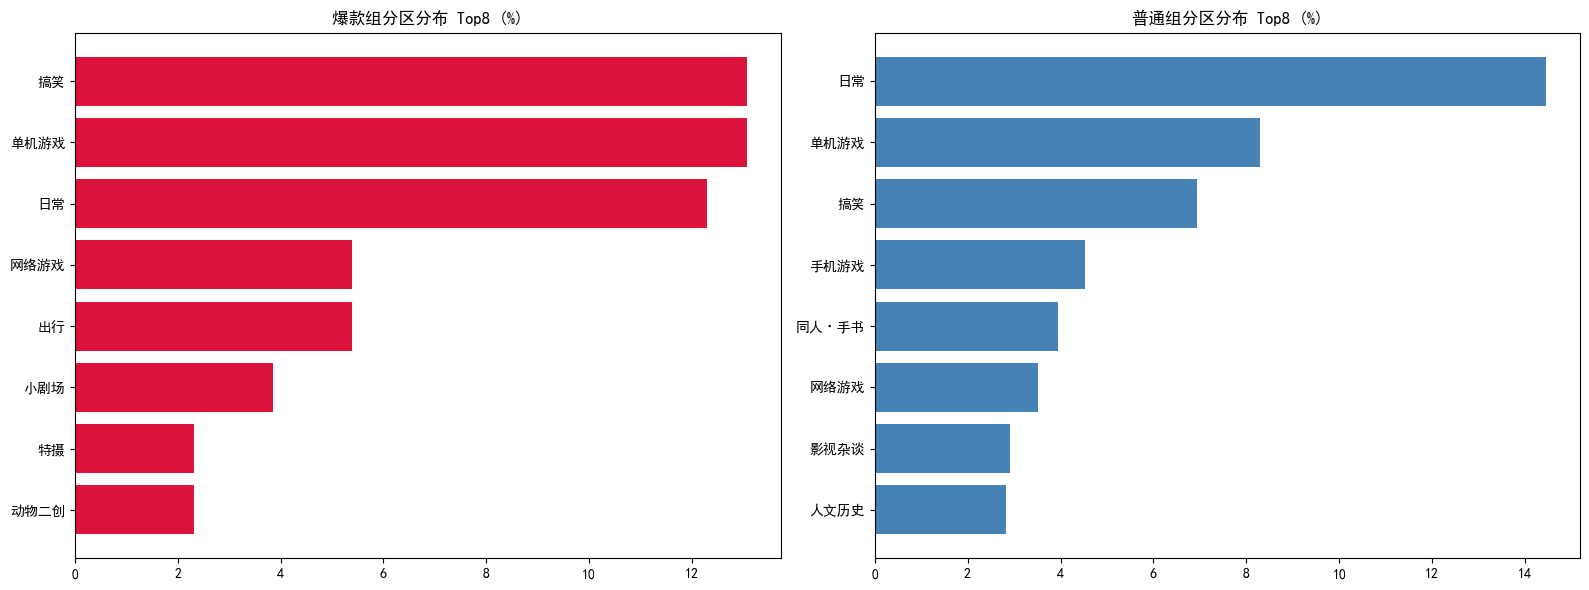

In [23]:
# ============ 5. 画图：爆款 vs 普通分区分布对比 ============
hit_part2 = (hit['分区'].value_counts(normalize=True) * 100).head(8)
normal_part2 = (normal['分区'].value_counts(normalize=True) * 100).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(hit_part2.index[::-1], hit_part2.values[::-1], color='crimson')
axes[0].set_title('爆款组分区分布 Top8 (%)')
axes[1].barh(normal_part2.index[::-1], normal_part2.values[::-1], color='steelblue')
axes[1].set_title('普通组分区分布 Top8 (%)')
plt.tight_layout()
plt.savefig('../reports/图5_爆款画像.png', dpi=150)
plt.show()

## 十二、爆款预测模型（逻辑回归）将"是否爆款"作为目标变量，训练逻辑回归模型。
**特征**：互动率、三连率、币赞比、弹幕密度、是否高爆款分区、是否周一到周四。> 不用绝对互动数作特征——它们和播放量高度共线，会污染回归系数。
**样本不平衡**：爆款仅占 10%，用 `class_weight='balanced'` 防止模型全猜"非爆款"。
**结论预期**：准确率约 0.70，但爆款类别 precision 仅 0.34（方向参考）；弹幕密度（+1.43）、投币率（+0.69）是爆款最强驱动，互动率普遍负权重。

In [24]:

# ============ 1. 构造特征 ============
# 目标：是否爆款（1=头部爆款+超级爆款，0=其他）
df['是否爆款'] = df['播放分层'].isin(['头部爆款', '超级爆款']).astype(int)

# 时长分箱（虚拟变量）
bins = [0, 60, 300, 900, 100000]
labels = ['0-1分钟', '1-5分钟', '5-15分钟', '15分钟+']
df['时长分箱'] = pd.cut(df['时长秒'], bins=bins, labels=labels)

# 分区：只保留爆款率最高的几个分区作为"分区标签"
top_parts = ['特摄', '小剧场', '搞笑', '影视剪辑', '出行']
df['高爆款分区'] = df['分区'].isin(top_parts).astype(int)

# 发布时间星期（受快照影响大，这里不强用，仅保留周一到周四作参考）
df['发布时间'] = pd.to_datetime(df['发布时间'])
df['周一到周四'] = (df['发布时间'].dt.dayofweek < 4).astype(int)

# 互动特征：用互动率 + 弹幕密度 + 三连率
# 注意：不用绝对互动数（和播放量高度共线，会污染系数）
feats = ['点赞率', '评论率', '弹幕率', '收藏率', '投币率', '分享率', '三连率', '币赞比', '弹幕密度', '高爆款分区', '周一到周四']

# 处理无穷值（除以 0 产生的 inf）和缺失
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=feats + ['是否爆款'])
print('有效样本:', len(df))

X = df[feats]
y = df['是否爆款']

# ============ 2. 标准化 + 划分训练测试 ============
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# ============ 3. 训练模型 ============
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# ============ 4. 评估 ============
from sklearn.metrics import accuracy_score, classification_report
print('\n测试集准确率:', round(accuracy_score(y_test, model.predict(X_test)), 3))
print(classification_report(y_test, model.predict(X_test)))

# ============ 5. 特征影响权重 ============
# 系数越大，该特征对"成为爆款"的正向贡献越大
print('\n特征影响权重（越大越促进爆款）:')
coef_df = pd.DataFrame({'特征': feats, '系数': model.coef_[0]})
coef_df['系数'] = coef_df['系数'].round(3)
coef_df = coef_df.sort_values('系数', ascending=False)
print(coef_df.to_string())

有效样本: 1299

测试集准确率: 0.715
              precision    recall  f1-score   support

           0       0.96      0.72      0.82       355
           1       0.20      0.71      0.31        35

    accuracy                           0.72       390
   macro avg       0.58      0.71      0.57       390
weighted avg       0.89      0.72      0.77       390


特征影响权重（越大越促进爆款）:
       特征     系数
8    弹幕密度  1.593
4     投币率  0.723
9   高爆款分区  0.333
5     分享率  0.153
3     收藏率  0.139
10  周一到周四 -0.221
6     三连率 -0.328
7     币赞比 -0.329
0     点赞率 -0.834
2     弹幕率 -0.998
1     评论率 -1.220


## 十三、结论与业务建议
1.**播放分布**：播放量右偏（均值÷中位=1.52），幂律分布，中位数才有代表性
2. **分区维度**：流量 ≠ 互动，大众区靠播放、小众区靠粘性；特摄（42.9%）、小剧场（40.0%）、搞笑（40.0%）最容易出爆款
3. **UP主维度**：前 14% 的 UP主贡献 50% 播放，头部高度集中；小 UP 出爆款样本为 0
4. **时长维度**：0-1 分钟短视频播放和三连率双第一，爆款整体偏短（206s vs 257s）
5. **互动规律**：高播放 ≠ 高互动率；**弹幕密度是唯一正相关指标（+0.543）**
6. **爆款信号**：弹幕密度（爆款 36.46 vs 普通 11.49，3.2 倍）+ 投币率，是爆款核心驱动
7. **建议**：   - 创作者优先进入特摄/小剧场/搞笑等爆款率高的分区，内容偏短   - 设计弹幕互动话题，制造弹幕活跃；投币是最硬核认可   - 平台需扶持腰部 UP主，避免流量过度集中；小众分区（VOCALOID、绘画）适合深度粉丝运营  